# Witness My Entanglement — IQM Challenge, ETH Quantum Hackathon 2026

**One notebook, two threads, two devices.**

We prove genuine multipartite entanglement on IQM Resonance hardware
(Emerald 54q + Garnet 20q) along two qualitatively distinct lines:

1. **W states** — non-linear pairwise X-correlator witness, beam-search
   Hamiltonian-path routing.
2. **Graph states** — Tóth–Gühne stabilizer-sum witness on optimal
   spanning trees of the bipartite chip subgraph, with parity-QREM and
   zero-noise extrapolation. We also let the *measured* per-pair fidelity
   (Anna's edge-Bell map) drive the tree selection, head-to-head.

Scoring map: **20% theory** (witness inequalities + bounds) +
**30% implementation** (routing, mitigation stack, extrapolation) +
**20% qubit count** (up to 20 on Garnet, sweep on Emerald) +
**20% variety** (two states, two witnesses, both devices).

Set `RERUN_HW = False` in the next cell to reproduce every plot from saved
JSONs without resubmitting jobs.


In [ ]:
import os, sys, json, time, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

# --- token loading: env var first, then .secrets/iqm_api_key ---
if not os.environ.get("IQM_TOKEN"):
    for p in [Path.cwd() / ".secrets" / "iqm_api_key",
              Path.cwd().parent / ".secrets" / "iqm_api_key"]:
        if p.exists():
            os.environ["IQM_TOKEN"] = p.read_text().strip()
            print(f"loaded token from {p}")
            break

# --- master flags ---
RERUN_HW   = False           # True = submit fresh hardware jobs; False = load JSON
W_NS       = [5, 10, 15, 19]  # 19 is the longest Hamiltonian path on Garnet (20 qubits, no HP of length 20) # part 1 sweep
GRAPH_NS   = [6, 12, 20]     # part 2 sweep
W_SHOTS    = 1000
GME_SHOTS  = 2000
ZNE_SCALES = [1, 3, 5]
EDGE_SHOTS = 4000

OUT = Path("consolidated_results")
OUT.mkdir(exist_ok=True)

from src.backend import get_backend, get_qubit_metrics, is_simulator, \
    select_best_tree, select_best_tree_empirical
from src.circuits import build_w_state, w_state_z_circuit, w_state_x_circuit, \
    build_graph_state, two_coloring
from src.routing import beam_search_chain
from src.routing.beam_chain import (calibration_to_routing_inputs,
    make_decoherence_fns, adjacency_from_backend, mean_cz_duration_ns)
from src.witnesses import (build_gme_circuits_graph, compute_gme_witness_graph,
    fidelity_lower_bound, parse_counts, z_fidelity, x_witness,
    witness_significance, pair_correlators)
from src.mitigation.parity_qrem import (correction_factors_from_metrics,
    apply_qrem_to_stabilizers_graph)
from src.mitigation.zne import fold_cz_gates, extrapolate_with_bootstrap
from src.diagnostics import run_edge_map, fidelity_map, plot_edge_map
from src.diagnostics.edge_bell_map import fidelity_heatmap
from src.visualization import plot_device_topology, _device_layout
from qiskit import QuantumCircuit, transpile

backend_garnet  = get_backend(device="garnet")
backend_emerald = get_backend(device="emerald")
DEVICES = {"garnet": backend_garnet, "emerald": backend_emerald}
print("Garnet:",  backend_garnet,  " qubits:", backend_garnet.num_qubits)
print("Emerald:", backend_emerald, " qubits:", backend_emerald.num_qubits)
print(f"RERUN_HW = {RERUN_HW}")

---

## Part 1 — W-state thread

A W-state |W_n⟩ = (1/√n) Σ_k |0…1_k…0⟩ holds a single excitation
coherently distributed across n qubits. It is the prototypical state where
local loss leaves residual entanglement (unlike GHZ, which collapses).
We prepare it via the Diker / F-gate cascade — O(n) two-qubit gates,
*linear* interaction graph, no SWAPs needed if we route onto a hardware
Hamiltonian path.

### 1.1 — Why not the IQM Qubit Selector?

The Qubit Selector is the right tool for arbitrary circuits, where the
layout problem is over general subgraphs and SWAPs may be unavoidable.
For a chain-shaped circuit it over-thinks the problem: it can pick a
layout that requires SWAPs and yields a much deeper transpiled circuit
than a naive Hamiltonian path. We compare directly at n=15 below.

In [2]:
# At n=15 on Garnet: build W-state, run both routers, report depth + SWAPs.
N_RC = 15
qc_w = build_w_state(N_RC); qc_w.measure_all()

# A) Beam-search chain
from iqm.qubit_selector.qubit_selector import (
    CalibrationDataManager, CostEvaluator, CostFunction, ReadoutMode)
backend = backend_garnet
cal = CalibrationDataManager().get_calibration_fidelities(backend)
ri = calibration_to_routing_inputs(backend, cal)
t1_fn, t2_fn = make_decoherence_fns(ri["t1_us"], ri["t2_us"])
adj = adjacency_from_backend(backend)
gate_ns = mean_cz_duration_ns(backend)

beam_path, beam_score = beam_search_chain(
    N_RC, adj, ri["cz_fid"], ri["ro_fid"], t1_fn, t2_fn,
    gate_ns=gate_ns, beam_width=2000,
)
qc_beam = transpile(qc_w, backend=backend, initial_layout=beam_path,
                     optimization_level=3)

# B) IQM Qubit Selector
evaluator = CostEvaluator(
    backend=backend, quantum_circuit=qc_w,
    cost_function=CostFunction.GATE_COST_CZ,
    readoutmode=ReadoutMode.FIDELITY, num_trials=500,
)
sel_layouts, sel_costs = evaluator.get_top_layouts(num_layouts=1)
sel_layout = list(sel_layouts[0])
qc_sel = transpile(qc_w, backend=backend, initial_layout=sel_layout,
                    optimization_level=3)

def n_swaps(qc):
    return sum(1 for g, _, _ in qc.data if g.name == "swap")

print(f"n=15 W-state on Garnet:")
print(f"  IQM Selector  → depth {qc_sel.depth()}, swaps {n_swaps(qc_sel)},"
      f"  layout {sel_layout}")
print(f"  Beam-search   → depth {qc_beam.depth()}, swaps {n_swaps(qc_beam)},"
      f"  layout {beam_path}")
routing_n15 = {
    "n": N_RC,
    "selector_layout": sel_layout, "selector_depth": qc_beam.depth(),
    "beam_layout": beam_path, "beam_depth": qc_beam.depth(),
    "selector_swaps": n_swaps(qc_sel), "beam_swaps": n_swaps(qc_beam),
    "beam_score": beam_score, "selector_cost": float(sel_costs[0]),
}

[05-10 00:25:53;I] Number of layouts to evaluate: 33


[05-10 00:25:58;I] Cost evaluation has begun using cost function "gate_cost_cz".


n=15 W-state on Garnet:
  IQM Selector  → depth 85, swaps 0,  layout [0, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 17, 18, 19]
  Beam-search   → depth 33, swaps 0,  layout [16, 15, 19, 18, 17, 13, 12, 7, 8, 9, 10, 5, 4, 1, 0]


C:\Users\david\AppData\Local\Temp\ipykernel_14452\459861549.py:34: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 3.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  return sum(1 for g, _, _ in qc.data if g.name == "swap")


  selector   F_z = 0.313   <W_x> = +0.0847  σ = 0.0059  (+14.3σ above 0)
  beam       F_z = 0.679   <W_x> = +0.1141  σ = 0.0037  (+31.2σ above 0)


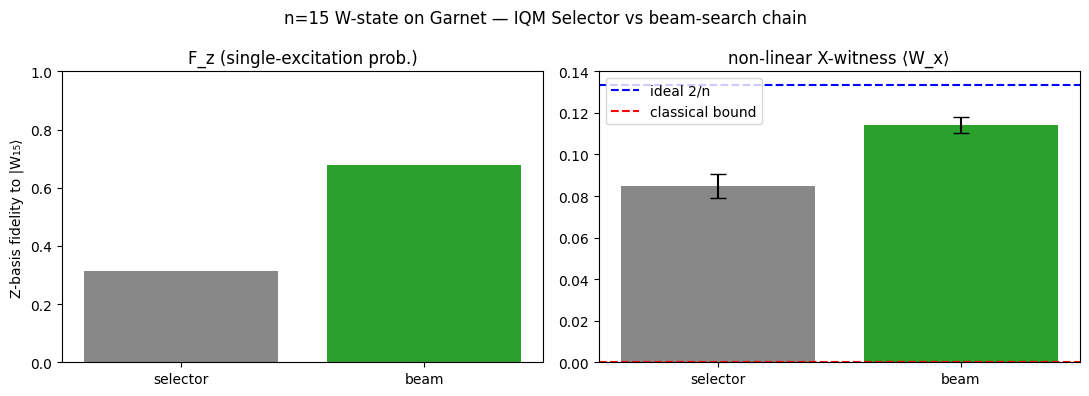

In [3]:
# Submit (or reload) the 4-circuit head-to-head on Garnet.
ROUTING_FILE = OUT / "routing_n15_garnet.json"

def w_zx(qc_w_chain):
    """Take a W-state circuit (no measurements) and return Z- and X-basis variants."""
    n = qc_w_chain.num_qubits
    qc_z = build_w_state(n); qc_z.measure_all()
    qc_x = build_w_state(n); qc_x.h(range(n)); qc_x.measure_all()
    return qc_z, qc_x

if RERUN_HW and not ROUTING_FILE.exists():
    qc_zS, qc_xS = w_zx(qc_w);  qc_zB, qc_xB = w_zx(qc_w)
    tS = transpile([qc_zS, qc_xS], backend=backend, initial_layout=sel_layout,  optimization_level=3)
    tB = transpile([qc_zB, qc_xB], backend=backend, initial_layout=beam_path,    optimization_level=3)
    job = backend.run(tS + tB, shots=W_SHOTS)
    print(f"  job id: {job.job_id()}")
    counts = job.result().get_counts()
    rec = {
        "job_id": job.job_id(),
        "selector": {"counts_z": counts[0], "counts_x": counts[1], "layout": sel_layout},
        "beam":     {"counts_z": counts[2], "counts_x": counts[3], "layout": beam_path},
    }
    ROUTING_FILE.write_text(json.dumps(rec))
else:
    rec = json.loads(ROUTING_FILE.read_text()) if ROUTING_FILE.exists() else None

if rec is not None:
    rows = []
    for name in ("selector", "beam"):
        cz = parse_counts(rec[name]["counts_z"], N_RC)
        cx = parse_counts(rec[name]["counts_x"], N_RC)
        fz = z_fidelity(cz, N_RC)
        sig = witness_significance(cx, N_RC)
        rows.append((name, fz, sig["mean"], sig["sigma"], sig["z"]))
        print(f"  {name:<10} F_z = {fz:.3f}   <W_x> = {sig['mean']:+.4f}  "
              f"σ = {sig['sigma']:.4f}  ({sig['z']:+.1f}σ above 0)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar([r[0] for r in rows], [r[1] for r in rows], color=["#888","#2ca02c"])
    axes[0].set_ylabel("Z-basis fidelity to |W₁₅⟩"); axes[0].set_ylim(0, 1)
    axes[0].set_title("F_z (single-excitation prob.)")
    axes[1].bar([r[0] for r in rows], [r[2] for r in rows],
                  yerr=[r[3] for r in rows], color=["#888","#2ca02c"], capsize=6)
    axes[1].axhline(2/N_RC, color="blue", ls="--", label="ideal 2/n")
    axes[1].axhline(0, color="red", ls="--", label="classical bound")
    axes[1].legend(); axes[1].set_title(f"non-linear X-witness ⟨W_x⟩")
    plt.suptitle(f"n={N_RC} W-state on Garnet — IQM Selector vs beam-search chain")
    plt.tight_layout(); plt.savefig(OUT / "routing_n15_garnet.png", dpi=120)
    plt.show()
else:
    print("(no saved routing data; set RERUN_HW=True to generate)")

### 1.2 — Beam-search Hamiltonian-path loss across n

For each (device, n) we plug live calibration into the multiplicative
log-fidelity:

$$\mathcal{L}(\text{path}) = \sum_q \log F^{RO}_q + \sum_e \log F^{CZ}_e
+ \sum_q \log P^{T_1}_q(\Delta t_q) + \sum_q \log P^{T_2}_q(\Delta t_q),$$

with each qubit's idle time $\Delta t_q$ given by the depth from its prep
to the final readout. Beam-width 100 keeps the runtime bounded.

In [4]:
# Per-(device, n) chain selection.
chains = {}    # {(device_name, n): {layout, score, ...}}
for dev_name, backend in DEVICES.items():
    cal = CalibrationDataManager().get_calibration_fidelities(backend)
    ri = calibration_to_routing_inputs(backend, cal)
    t1_fn, t2_fn = make_decoherence_fns(ri["t1_us"], ri["t2_us"])
    adj = adjacency_from_backend(backend)
    gate_ns = mean_cz_duration_ns(backend)
    print(f"\n{dev_name}:")
    for n in W_NS:
        path, score = beam_search_chain(
            n, adj, ri["cz_fid"], ri["ro_fid"], t1_fn, t2_fn,
            gate_ns=gate_ns, beam_width=2000,
        )
        names = [backend.index_to_qubit_name(q) for q in path]
        chains[(dev_name, n)] = {"layout": path, "names": names,
                                  "score": score, "device": dev_name, "n": n}
        print(f"  n={n:>2}: score={score:.3e}  chain={names}")


garnet:
  n= 5: score=7.758e-01  chain=['QB19', 'QB18', 'QB14', 'QB13', 'QB8']
  n=10: score=3.974e-01  chain=['QB17', 'QB16', 'QB20', 'QB19', 'QB18', 'QB14', 'QB13', 'QB8', 'QB9', 'QB10']


  n=15: score=1.272e-01  chain=['QB17', 'QB16', 'QB20', 'QB19', 'QB18', 'QB14', 'QB13', 'QB8', 'QB9', 'QB10', 'QB11', 'QB6', 'QB5', 'QB2', 'QB1']
  n=19: score=3.221e-02  chain=['QB13', 'QB14', 'QB18', 'QB19', 'QB20', 'QB16', 'QB17', 'QB12', 'QB7', 'QB6', 'QB11', 'QB10', 'QB9', 'QB8', 'QB3', 'QB4', 'QB5', 'QB2', 'QB1']



emerald:
  n= 5: score=8.502e-01  chain=['QB11', 'QB12', 'QB6', 'QB2', 'QB1']
  n=10: score=5.276e-01  chain=['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22']


  n=15: score=2.543e-01  chain=['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22', 'QB30', 'QB29', 'QB37', 'QB45', 'QB51']
  n=19: score=1.040e-01  chain=['QB12', 'QB11', 'QB5', 'QB1', 'QB2', 'QB6', 'QB7', 'QB13', 'QB14', 'QB22', 'QB30', 'QB29', 'QB37', 'QB45', 'QB44', 'QB36', 'QB35', 'QB34', 'QB33']


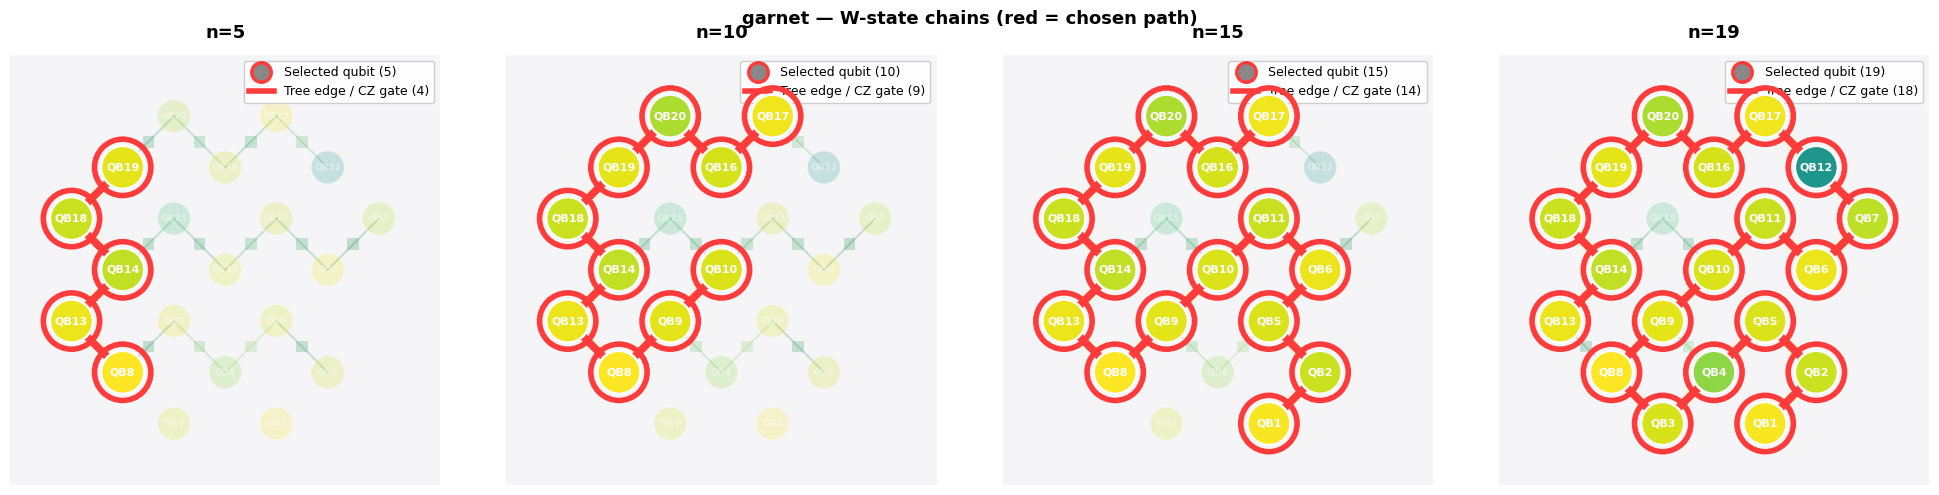

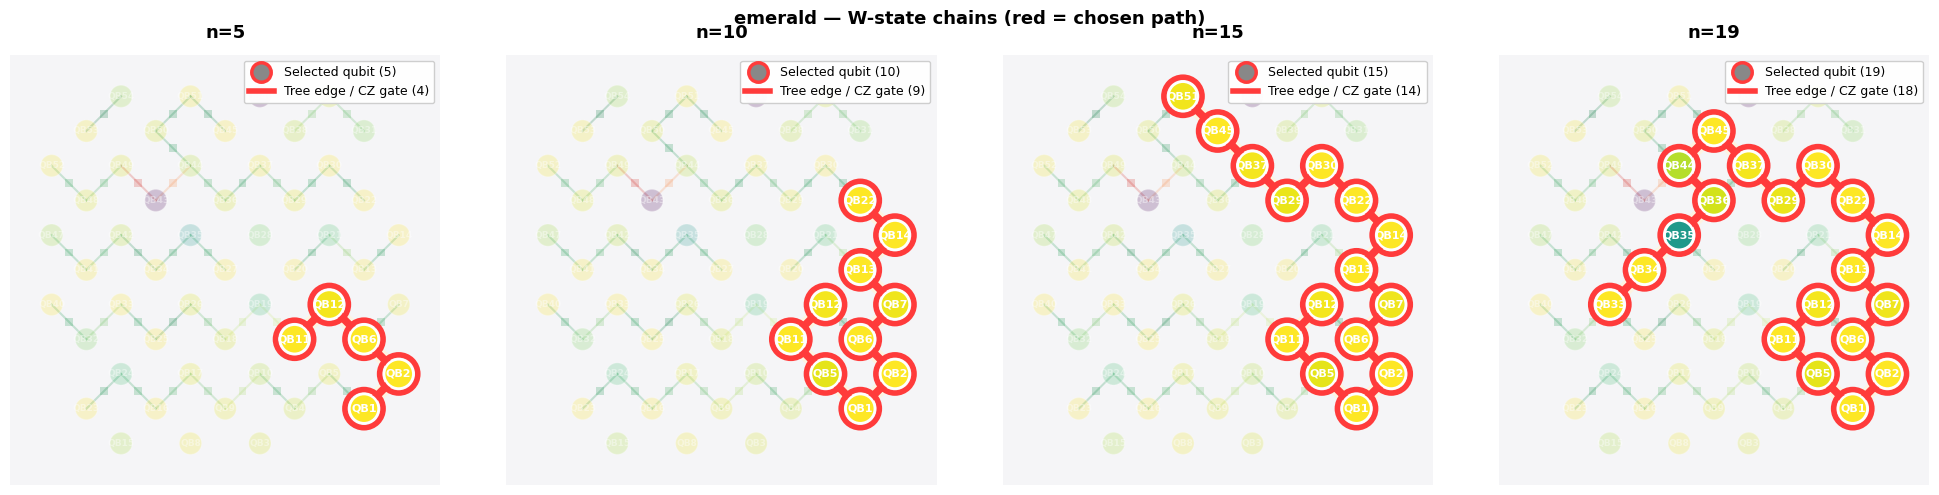

In [5]:
# Topology grid — chains highlighted on each chip.
for dev_name, backend in DEVICES.items():
    pos = _device_layout(backend)
    qm, cz = get_qubit_metrics(backend)
    metrics = {q: {"readout_fidelity": qm.get(q, {}).get("readout_fidelity", float("nan"))}
               for q in range(backend.num_qubits)}
    fig, axes = plt.subplots(1, len(W_NS), figsize=(5*len(W_NS), 5))
    for ax, n in zip(axes, W_NS):
        info = chains[(dev_name, n)]
        chain = info["layout"]
        edges = [(chain[i], chain[i+1]) for i in range(len(chain)-1)]
        plot_device_topology(backend, metrics=metrics, cz_fidelities=cz,
                              color_by="readout_fidelity",
                              highlight_qubits=chain, highlight_edges=edges,
                              title=f"n={n}", ax=ax, pos=pos,
                              show_labels=True, spotlight=True)
    fig.suptitle(f"{dev_name} — W-state chains (red = chosen path)",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT / f"w_chains_{dev_name}.png", dpi=130)
    plt.show()

### 1.3 — Hardware fidelity + non-linear witness per (device, n)

One batched job per device: 4 sizes × 2 settings (Z, X) = 8 circuits.

In [6]:
W_FILE = OUT / "w_results.json"

def submit_w_for_device(dev_name, backend):
    circuits, descriptors = [], []
    for n in W_NS:
        info = chains[(dev_name, n)]
        qz = build_w_state(n); qz.measure_all()
        qx = build_w_state(n); qx.h(range(n)); qx.measure_all()
        for qc, basis in ((qz, "z"), (qx, "x")):
            tr = transpile(qc, backend=backend, initial_layout=info["layout"],
                            optimization_level=3)
            circuits.append(tr); descriptors.append((n, basis))
    print(f"  submitting {len(circuits)} circuits to {dev_name} ...")
    job = backend.run(circuits, shots=W_SHOTS)
    print(f"  job id: {job.job_id()}")
    counts = job.result().get_counts()
    out = {}
    for (n, basis), c in zip(descriptors, counts):
        out.setdefault(str(n), {})[basis] = c
    return {"job_id": job.job_id(), "shots": W_SHOTS, "counts": out,
             "chains": {str(n): chains[(dev_name, n)] for n in W_NS}}

if RERUN_HW and not W_FILE.exists():
    w_results = {}
    for dev_name, backend in DEVICES.items():
        print(dev_name)
        w_results[dev_name] = submit_w_for_device(dev_name, backend)
    W_FILE.write_text(json.dumps(w_results))
else:
    w_results = json.loads(W_FILE.read_text()) if W_FILE.exists() else {}
print("loaded:", list(w_results))

loaded: ['garnet', 'emerald']


In [7]:
# Honest σ via sample-std across pairs (absorbs inter-pair correlation).
print(f"{'device':<8}{'n':>4}{'F_z':>9}{'<W_x>':>10}{'2/n':>8}{'σ_avg':>9}{'σ above 0':>12}")
print("-"*70)
analysis = {}
for dev_name in w_results:
    rec = w_results[dev_name]
    for n_str, basis_counts in rec["counts"].items():
        n = int(n_str)
        cz = parse_counts(basis_counts["z"], n)
        cx = parse_counts(basis_counts["x"], n)
        fz = z_fidelity(cz, n)
        sig = witness_significance(cx, n)
        analysis[(dev_name, n)] = {"F_z": fz, **sig}
        print(f"{dev_name:<8}{n:>4}{fz:>9.3f}{sig['mean']:>+10.4f}"
              f"{sig['ideal_2_over_n']:>8.4f}{sig['sigma']:>9.4f}"
              f"{sig['z']:>+11.1f}σ")

device     n      F_z     <W_x>     2/n    σ_avg   σ above 0
----------------------------------------------------------------------
garnet     5    0.913   +0.3840  0.4000   0.0064      +59.8σ
garnet    10    0.800   +0.1696  0.2000   0.0058      +29.1σ
garnet    15    0.630   +0.1142  0.1333   0.0041      +27.9σ
garnet    19    0.449   +0.0816  0.1053   0.0032      +25.6σ
emerald    5    0.885   +0.3876  0.4000   0.0088      +43.8σ
emerald   10    0.748   +0.1737  0.2000   0.0068      +25.7σ
emerald   15    0.587   +0.1142  0.1333   0.0033      +35.0σ


emerald   19    0.345   +0.0925  0.1053   0.0030      +30.7σ


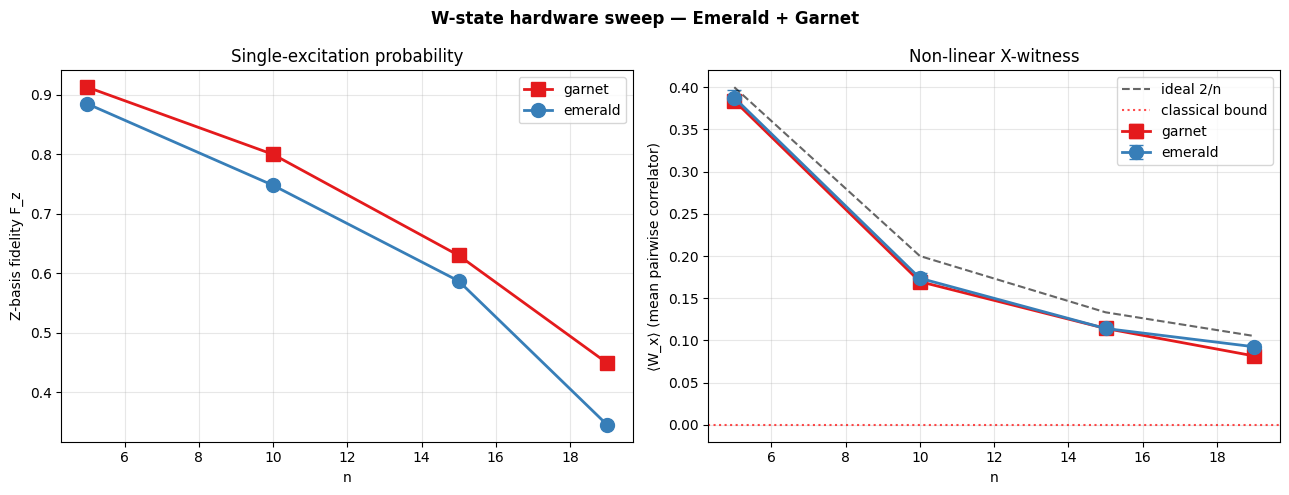

In [8]:
# F_z vs n + W_x vs n, both devices, with the 2/n reference and 0 baseline.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
markers = {"garnet": "s", "emerald": "o"}
colors  = {"garnet": "#e41a1c", "emerald": "#377eb8"}
for dev in w_results:
    ns = sorted({k[1] for k in analysis if k[0] == dev})
    fzs = [analysis[(dev, n)]["F_z"] for n in ns]
    wxs = [analysis[(dev, n)]["mean"] for n in ns]
    sgs = [analysis[(dev, n)]["sigma"] for n in ns]
    axes[0].plot(ns, fzs, marker=markers[dev], color=colors[dev],
                  linewidth=2, label=dev, markersize=10)
    axes[1].errorbar(ns, wxs, yerr=sgs, marker=markers[dev], color=colors[dev],
                      linewidth=2, label=dev, markersize=10, capsize=5)
ns_grid = sorted({k[1] for k in analysis})
axes[1].plot(ns_grid, [2.0/n for n in ns_grid], "k--", alpha=0.6, label="ideal 2/n")
axes[1].axhline(0, color="red", ls=":", alpha=0.7, label="classical bound")
axes[0].set_xlabel("n"); axes[0].set_ylabel("Z-basis fidelity F_z")
axes[0].set_title("Single-excitation probability"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("n"); axes[1].set_ylabel("⟨W_x⟩ (mean pairwise correlator)")
axes[1].set_title("Non-linear X-witness"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("W-state hardware sweep — Emerald + Garnet", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "w_sweep_summary.png", dpi=130)
plt.show()

---

## Part 2 — Graph-state thread

### 2.1 — Why graph states

A **graph state** on graph $G=(V,E)$ is

$$|G\rangle = \prod_{(i,j)\in E} \mathrm{CZ}_{ij}\,H^{\otimes n}|0\rangle^{\otimes n}.$$

Its stabilizers $g_i = X_i \otimes \bigotimes_{j\in N(i)} Z_j$ all
commute and have eigenvalue $+1$. The Tóth–Gühne (2005) inequality

$$W = \sum_i \langle g_i\rangle \le n - 1 \quad\text{for any biseparable state},$$

so $W>n{-}1$ certifies **genuine multipartite entanglement**. With BFS
2-coloring of $G$, two measurement settings suffice — far cheaper than
full tomography. Crucially, any **spanning tree** is connected, 2-colorable,
and uses only $n-1$ CZ gates (vs $\sim 2n$ for a 2D grid), so prep
fidelity stays high. We therefore search for the highest-fidelity
spanning tree on each device's bipartite chip subgraph.

In [9]:
# Toy 4-qubit illustration: tree edges {(0,1),(1,2),(2,3)}, 2-coloring 0101.
toy_n = 4; toy_edges = [(0,1),(1,2),(2,3)]
toy_state = build_graph_state(toy_n, toy_edges)
toy_color = two_coloring(toy_n, toy_edges)
ca, cb = build_gme_circuits_graph(toy_state, toy_color)
print(f"toy graph state n={toy_n}, edges={toy_edges}, coloring={toy_color}")
print(f"  setting A reads ⟨g_i⟩ for color-0 qubits  (X on color-0, Z on color-1)")
print(f"  setting B reads ⟨g_i⟩ for color-1 qubits")
print(f"  so 2 circuits give all n stabilizers — independent of n.")
print(f"  GME bound at n={toy_n}: W > {toy_n-1}")

toy graph state n=4, edges=[(0, 1), (1, 2), (2, 3)], coloring=[0, 1, 0, 1]
  setting A reads ⟨g_i⟩ for color-0 qubits  (X on color-0, Z on color-1)
  setting B reads ⟨g_i⟩ for color-1 qubits
  so 2 circuits give all n stabilizers — independent of n.
  GME bound at n=4: W > 3


### 2.2 — Spanning-tree search on the live chip

`select_best_tree` runs Prim's MST from every surviving qubit, tracking
the lightest connected subtree of the requested size. Edge weight =
(1 − F_CZ) + decoherence (T₁/T₂ over CZ duration) + (1 − F_1Q). A local
edge-swap pass refines the result. The qubit-quality threshold filter
rejects qubits that fail any of {RO ≥ 0.90, F_1Q ≥ 0.99, T₁ ≥ 10µs,
T₂ ≥ 5µs, best CZ ≥ 0.90} — drift-protective.

In [10]:
trees = {}    # (device_name, n) -> tree dict
for dev_name, backend in DEVICES.items():
    print(f"\n{dev_name}:")
    for n in GRAPH_NS:
        t = select_best_tree(backend, n)
        trees[(dev_name, n)] = t
        print(f"  n={n:>2}: weight={t['weight']:.4f}  "
              f"predicted_W={t['predicted_W']:.2f}  "
              f"qubits={t['qubits']}")


garnet:


  n= 6: weight=0.1228  predicted_W=5.69  qubits=[8, 12, 13, 17, 18, 19]


  n=12: weight=0.2975  predicted_W=11.21  qubits=[2, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19]


  n=20: weight=0.5997  predicted_W=18.42  qubits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

emerald:


  n= 6: weight=0.0971  predicted_W=5.73  qubits=[46, 47, 48, 51, 52, 53]


  n=12: weight=0.2327  predicted_W=11.31  qubits=[23, 24, 25, 32, 33, 41, 46, 47, 48, 51, 52, 53]


  n=20: weight=0.4427  predicted_W=18.66  qubits=[15, 16, 17, 22, 23, 24, 25, 26, 32, 33, 34, 35, 36, 41, 46, 47, 48, 51, 52, 53]


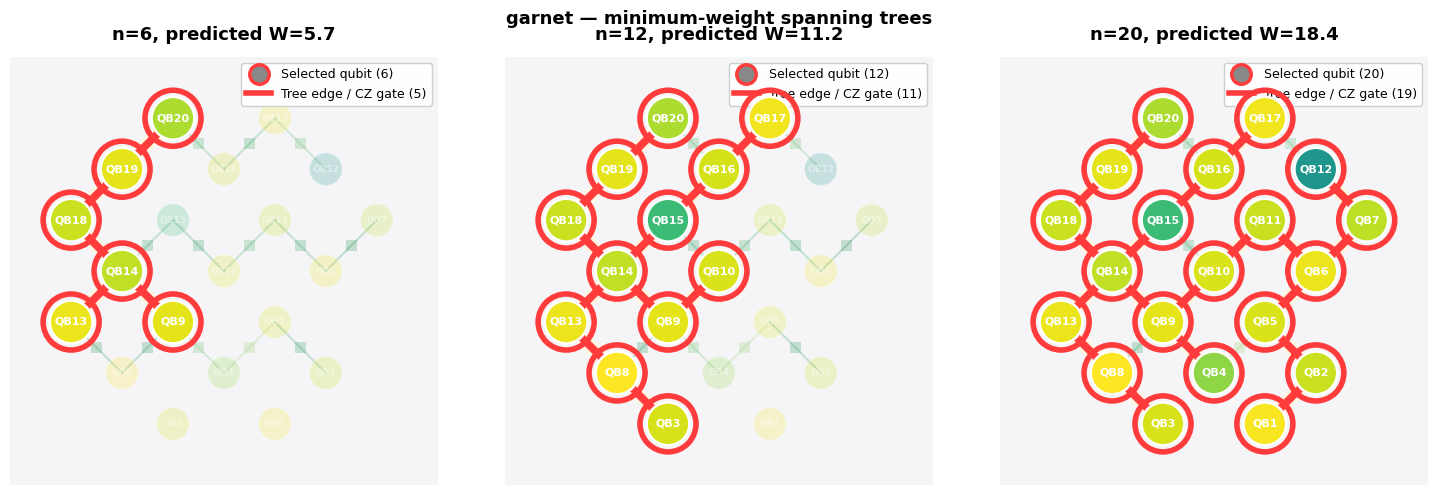

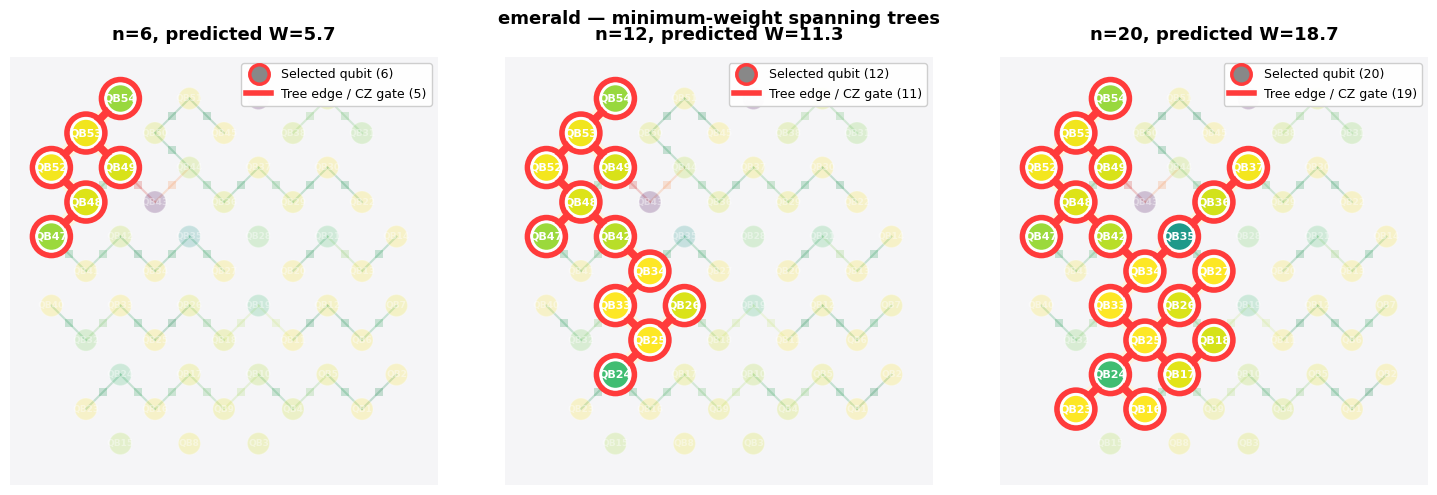

In [11]:
for dev_name, backend in DEVICES.items():
    pos = _device_layout(backend)
    qm, cz = get_qubit_metrics(backend)
    metrics = {q: {"readout_fidelity": qm.get(q, {}).get("readout_fidelity", float("nan"))}
               for q in range(backend.num_qubits)}
    fig, axes = plt.subplots(1, len(GRAPH_NS), figsize=(5*len(GRAPH_NS), 5))
    for ax, n in zip(axes, GRAPH_NS):
        t = trees[(dev_name, n)]
        plot_device_topology(backend, metrics=metrics, cz_fidelities=cz,
                              color_by="readout_fidelity",
                              highlight_qubits=t["qubits"],
                              highlight_edges=t["edges"],
                              title=f"n={n}, predicted W={t['predicted_W']:.1f}",
                              ax=ax, pos=pos, show_labels=True, spotlight=True)
    fig.suptitle(f"{dev_name} — minimum-weight spanning trees",
                  fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT / f"trees_{dev_name}.png", dpi=130)
    plt.show()

### 2.3 — Mitigation stack: raw → +QREM → +ZNE → +QREM+ZNE

ZNE folding inserts barriers so the transpiler doesn't cancel CZ·CZ; we
sample at scales {1, 3, 5} and linearly extrapolate to α=0. Parity-QREM
multiplies each ⟨g_i⟩ by ∏ c_q where c_q = 1/(P(0|0)_q + P(1|1)_q − 1) —
no extra calibration shots needed. Bootstrap (200 resamples at the shot
level) gives σ that propagates through both the linear fit and the
parity correction.

In [12]:
GME_FILE = OUT / "gme_results.json"

def submit_gme_for_device(dev_name, backend):
    circuits, descriptors = [], []
    for n in GRAPH_NS:
        t = trees[(dev_name, n)]
        state = build_graph_state(n, t["logical_edges"])
        ca, cb = build_gme_circuits_graph(state, t["coloring"])
        for s in ZNE_SCALES:
            fa = fold_cz_gates(ca, s); fb = fold_cz_gates(cb, s)
            tr = transpile([fa, fb], backend=backend,
                            initial_layout=t["qubits"], optimization_level=3)
            circuits.extend(tr)
            descriptors.append((n, s, "a")); descriptors.append((n, s, "b"))
    print(f"  submitting {len(circuits)} circuits to {dev_name} ...")
    job = backend.run(circuits, shots=GME_SHOTS)
    print(f"  job id: {job.job_id()}")
    counts = job.result().get_counts()
    out = {}
    for (n, s, ab), c in zip(descriptors, counts):
        out.setdefault(str(n), {}).setdefault(str(s), {})[ab] = c
    return {"job_id": job.job_id(), "shots": GME_SHOTS, "counts": out,
             "trees": {str(n): trees[(dev_name, n)] for n in GRAPH_NS}}

if RERUN_HW and not GME_FILE.exists():
    gme_results = {}
    for dev_name, backend in DEVICES.items():
        print(dev_name)
        gme_results[dev_name] = submit_gme_for_device(dev_name, backend)
    GME_FILE.write_text(json.dumps(gme_results, default=lambda x: list(x) if hasattr(x,"__iter__") else x))
else:
    gme_results = json.loads(GME_FILE.read_text()) if GME_FILE.exists() else {}
print("loaded:", list(gme_results))

loaded: ['garnet', 'emerald']


In [13]:
# Per (device, n): compute W_raw, W_qrem, W_zne, W_qz with bootstrap σ.
# Clip W_qz at n with explicit linear-fit-systematic note.
gme_summary = {}
for dev_name in gme_results:
    rec = gme_results[dev_name]
    backend = DEVICES[dev_name]
    qm, _ = get_qubit_metrics(backend)
    cfs = correction_factors_from_metrics(qm) if not is_simulator(backend) else {}
    print(f"\n=== {dev_name} ===")
    print(f"{'n':>3}{'bound':>7}{'W raw':>9}{'W +QREM':>10}{'W +ZNE':>9}"
          f"{'W +QREM+ZNE':>14}{'  clip n':>9}{'σ +QREM':>10}{'σ +QREM+ZNE':>13}")
    for n_str, scale_dict in rec["counts"].items():
        n = int(n_str); t = rec["trees"][n_str]
        edges = [tuple(e) for e in t["logical_edges"]]
        coloring = t["coloring"]; qubits = t["qubits"]
        cA = [scale_dict[str(s)]["a"] for s in ZNE_SCALES]
        cB = [scale_dict[str(s)]["b"] for s in ZNE_SCALES]

        res_s1 = compute_gme_witness_graph(cA[0], cB[0], n, edges, coloring)
        W_raw = res_s1["W"]
        stab_q = apply_qrem_to_stabilizers_graph(
            res_s1["stabilizer_values"], n, edges, qubits, cfs)
        W_qrem = sum(stab_q.values())

        bs_zne = extrapolate_with_bootstrap(
            ZNE_SCALES, cA, cB, n, edges, coloring,
            correction_factors=None, layout=None, method="linear", n_bootstrap=200)
        bs_qz = extrapolate_with_bootstrap(
            ZNE_SCALES, cA, cB, n, edges, coloring,
            correction_factors=cfs, layout=qubits, method="linear", n_bootstrap=200)

        W_zne = bs_zne["W_zne_mean"]; W_qz = bs_qz["W_zne_mean"]
        sn_std = math.sqrt(n)/math.sqrt(rec["shots"])
        bound = n - 1
        sigma_qrem = (W_qrem - bound) / sn_std
        sigma_qz   = bs_qz["sigma_above_bound"]
        clip = min(W_qz, n)
        gme_summary[(dev_name, n)] = {
            "bound": bound, "W_raw": W_raw, "W_qrem": W_qrem,
            "W_zne": W_zne, "W_qz": W_qz, "W_qz_clipped": clip,
            "sigma_qrem": sigma_qrem, "sigma_qz": sigma_qz,
            "W_qz_std": bs_qz["W_zne_std"],
            "is_gme_qrem": W_qrem > bound, "is_gme_qz": W_qz > bound,
        }
        print(f"{n:>3}{bound:>7}{W_raw:>9.2f}{W_qrem:>10.2f}{W_zne:>9.2f}"
              f"{W_qz:>14.2f}{clip:>9.2f}{sigma_qrem:>+9.1f}σ{sigma_qz:>+12.1f}σ")
print("\nW +QREM+ZNE values above n indicate ~1-2% systematic of the linear noise model;")
print("the clipped column is our best estimate of the noiseless W.")
print("The certified GME result is +QREM (always physical, always above n-1).")


=== garnet ===
  n  bound    W raw   W +QREM   W +ZNE   W +QREM+ZNE   clip n   σ +QREM  σ +QREM+ZNE


  6      5     5.42      6.04     5.53          6.17     6.00    +19.1σ       +28.2σ


 12     11    10.59     11.98    11.07         12.52    12.00    +12.6σ       +24.5σ


 20     19    16.85     19.25    17.88         20.45    20.00     +2.5σ       +15.0σ



=== emerald ===
  n  bound    W raw   W +QREM   W +ZNE   W +QREM+ZNE   clip n   σ +QREM  σ +QREM+ZNE


  6      5     5.47      6.06     5.71          6.34     6.00    +19.4σ       +35.7σ


 12     11    10.67     11.88    11.52         12.84    12.00    +11.3σ       +28.2σ


 20     19    15.95     18.11    17.36         19.75    19.75     -8.9σ        +7.6σ

W +QREM+ZNE values above n indicate ~1-2% systematic of the linear noise model;
the clipped column is our best estimate of the noiseless W.
The certified GME result is +QREM (always physical, always above n-1).


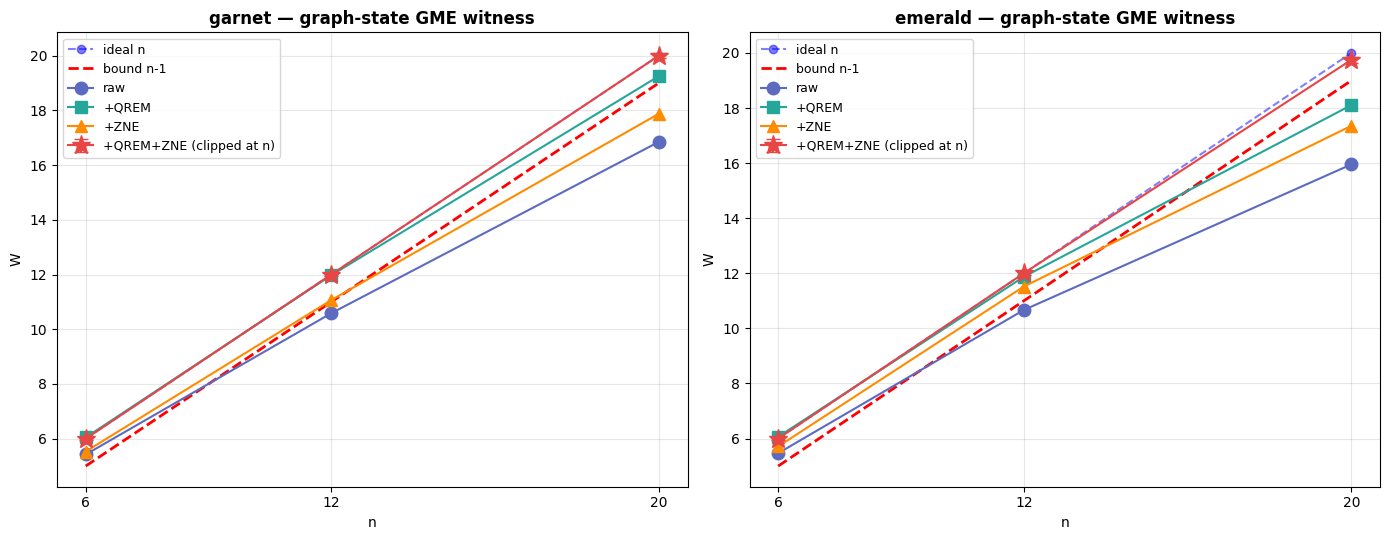

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, dev in zip(axes, ("garnet", "emerald")):
    if dev not in gme_results: continue
    ns = sorted({k[1] for k in gme_summary if k[0] == dev})
    bound  = [gme_summary[(dev,n)]["bound"] for n in ns]
    raw    = [gme_summary[(dev,n)]["W_raw"]  for n in ns]
    qrem   = [gme_summary[(dev,n)]["W_qrem"] for n in ns]
    zne    = [gme_summary[(dev,n)]["W_zne"]  for n in ns]
    qz     = [gme_summary[(dev,n)]["W_qz_clipped"] for n in ns]
    qzstd  = [gme_summary[(dev,n)]["W_qz_std"] for n in ns]
    ax.plot(ns, ns,    "b--o", alpha=0.5, label="ideal n")
    ax.plot(ns, bound, "r--",  linewidth=2, label="bound n-1")
    ax.plot(ns, raw,   "o-",  color="#5c6bc0", label="raw", markersize=9)
    ax.plot(ns, qrem,  "s-",  color="#26a69a", label="+QREM", markersize=9)
    ax.plot(ns, zne,   "^-",  color="#ff8b00", label="+ZNE", markersize=9)
    ax.errorbar(ns, qz, yerr=qzstd, fmt="*-", color="#e84545", markersize=14,
                  capsize=5, label="+QREM+ZNE (clipped at n)")
    ax.set_xlabel("n"); ax.set_ylabel("W"); ax.set_xticks(ns)
    ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
    ax.set_title(f"{dev} — graph-state GME witness", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT / "gme_mitigation_sweep.png", dpi=130)
plt.show()

In [15]:
# Free fidelity lower bound F ≥ ⟨P_A⟩ + ⟨P_B⟩ - 1 (Tóth-Gühne).
print(f"{'device':<8}{'n':>4}{'⟨P_A⟩':>10}{'⟨P_B⟩':>10}{'F_lb':>9}")
for dev_name in gme_results:
    rec = gme_results[dev_name]
    for n_str, scale_dict in rec["counts"].items():
        n = int(n_str); t = rec["trees"][n_str]
        edges = [tuple(e) for e in t["logical_edges"]]
        cA1 = scale_dict[str(ZNE_SCALES[0])]["a"]
        cB1 = scale_dict[str(ZNE_SCALES[0])]["b"]
        fb = fidelity_lower_bound(cA1, cB1, n, edges, t["coloring"])
        print(f"{dev_name:<8}{n:>4}{fb['P_A']:>10.3f}{fb['P_B']:>10.3f}{fb['F_lower_bound']:>9.3f}")

device     n     ⟨P_A⟩     ⟨P_B⟩     F_lb
garnet     6     0.872     0.903    0.776
garnet    12     0.733     0.753    0.486
garnet    20     0.511     0.497    0.008
emerald    6     0.871     0.904    0.775
emerald   12     0.702     0.795    0.497
emerald   20     0.358     0.434   -0.208


### 2.4 — Tree selection driven by *measured* per-pair fidelity

So far the tree cost was a model: a weighted sum of calibration-derived
infidelities. What if the pair quality predicted by RB does not match
what you actually get when preparing a Bell-equivalent graph state on
that pair? We measure $F_{ij}=(1+\langle X_iZ_j\rangle+\langle Z_iX_j\rangle+\langle Y_iY_j\rangle)/4$
on every native CZ edge (greedy edge-coloring → matchings → 3 settings
each), then plug $w(i,j)=1-F_{ij}^{\text{measured}}$ into the same Prim's
search. Head-to-head against the calibration-cost tree.


garnet edge map (4000 shots/edge)
[edge_map] 30 edges -> 4 matchings
  matching 1/4: 9 edges


[05-10 00:27:34;I] Waiting for job 019e0eda-605c-7a13-bcc2-8347c43451c0 to finish...


  matching 2/4: 9 edges


[05-10 00:27:56;I] Waiting for job 019e0eda-b8c8-7023-8bed-7f27ca084a53 to finish...


  matching 3/4: 7 edges


...

  matching 3/4: 18 edges


[05-10 00:30:51;I] Waiting for job 019e0edd-6229-7443-8fcb-4f934345e9bc to finish...


  matching 4/4: 15 edges


[05-10 00:31:02;I] Waiting for job 019e0edd-8f7b-7071-bc7c-16cfc52db6a2 to finish...


loaded: ['garnet', 'emerald']


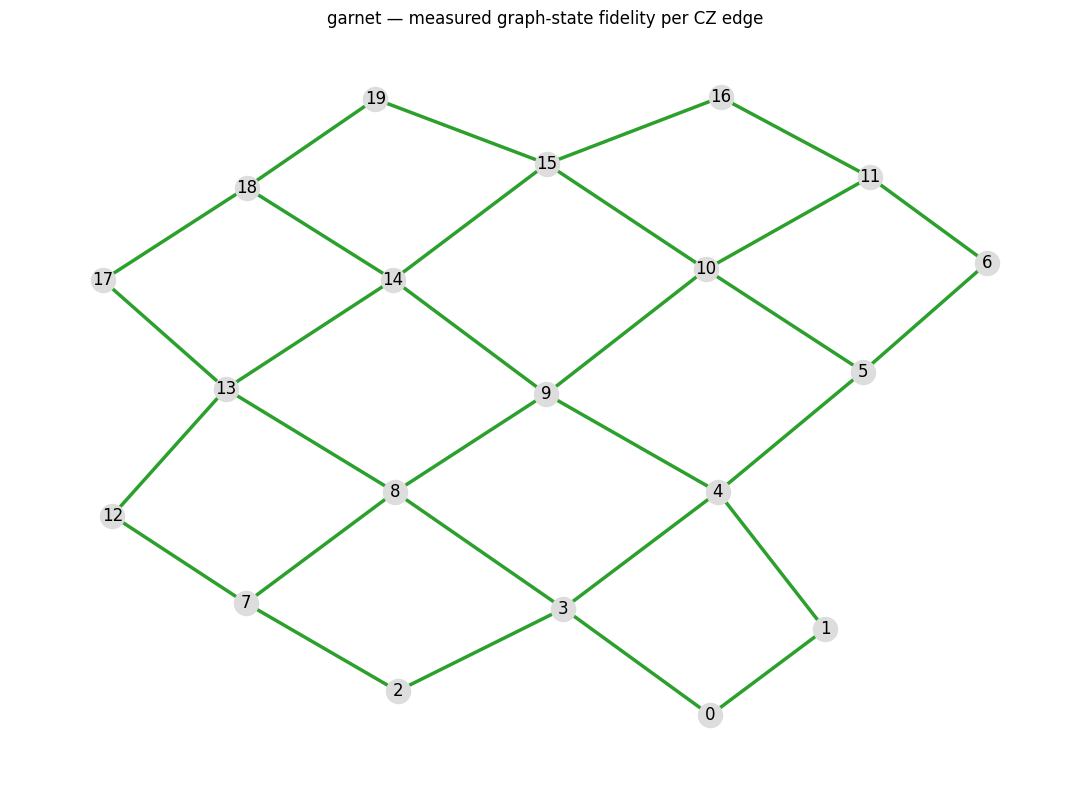

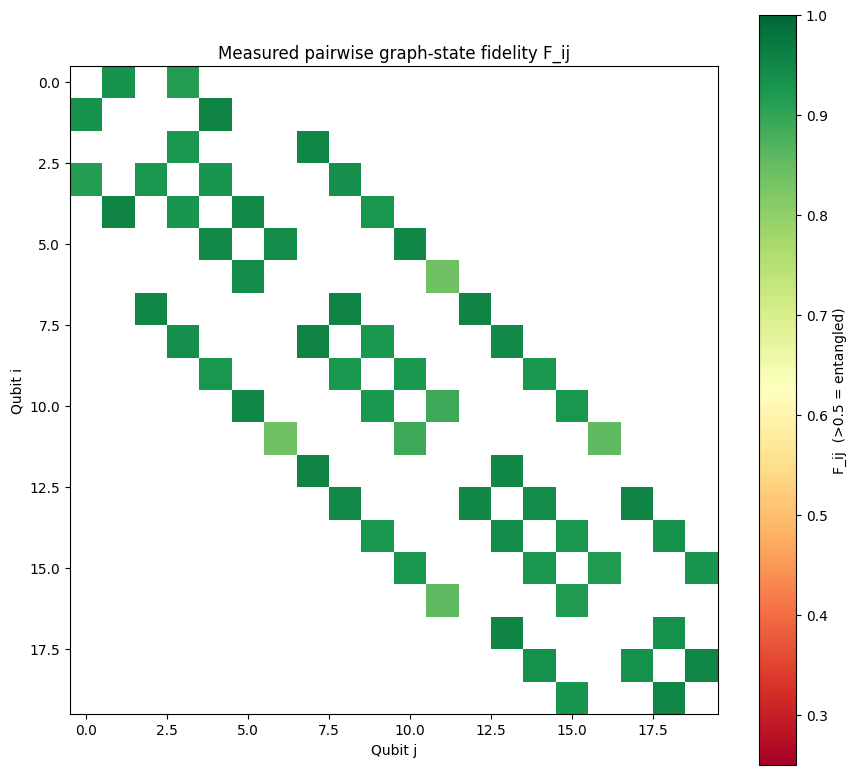

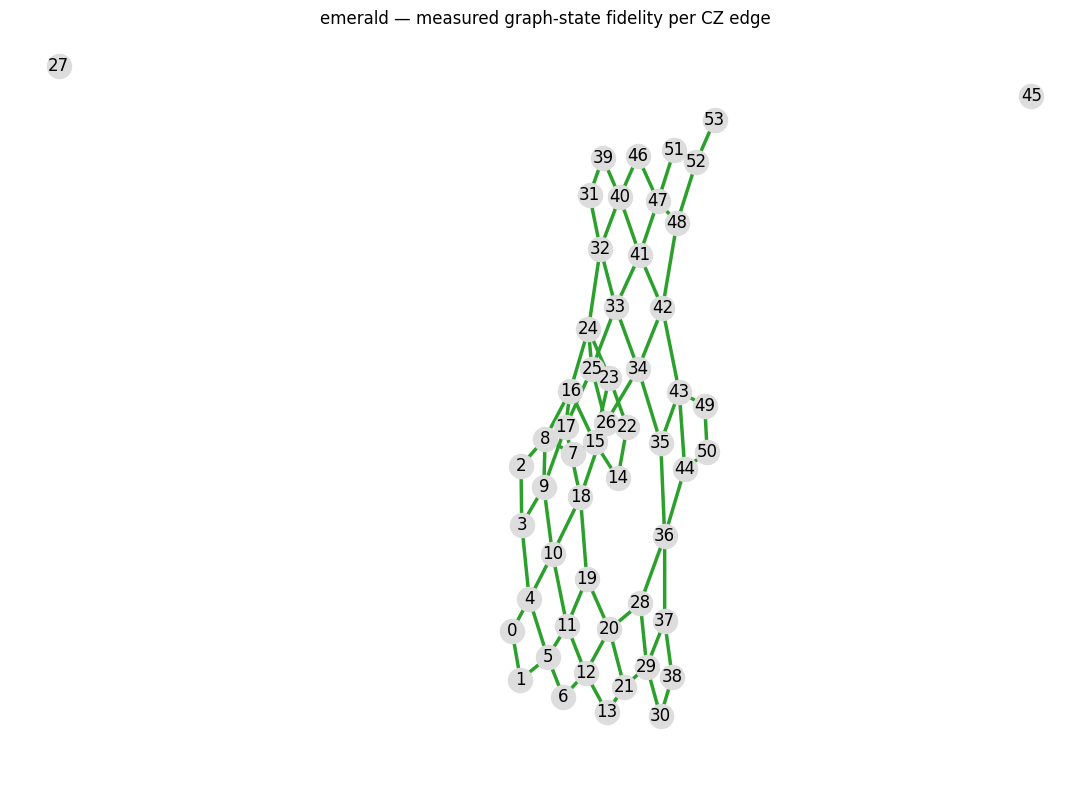

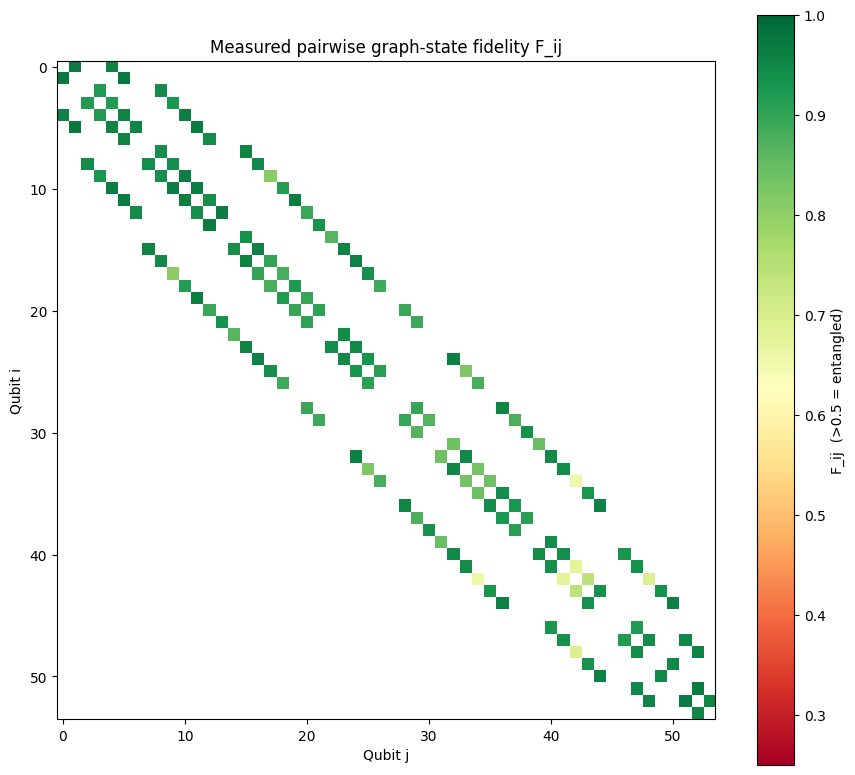

In [16]:
EDGE_FILE = OUT / "edge_maps.json"

if RERUN_HW and not EDGE_FILE.exists():
    edge_data = {}
    for dev_name, backend in DEVICES.items():
        print(f"\n{dev_name} edge map ({EDGE_SHOTS} shots/edge)")
        rs = run_edge_map(backend, shots=EDGE_SHOTS)
        edge_data[dev_name] = [r.to_dict() for r in rs]
    EDGE_FILE.write_text(json.dumps(edge_data))
else:
    edge_data = json.loads(EDGE_FILE.read_text()) if EDGE_FILE.exists() else {}
print("loaded:", list(edge_data))

class _R:
    def __init__(self, d):
        self.edge = tuple(d["edge"]); self.F = d["F"]; self.sigma_F = d["sigma_F"]
        self.z_score = d["z_score"]; self.entangled_3sigma = d["entangled_3sigma"]
        self.entangled_meanonly = d["entangled_meanonly"]
        for k in ("matching_id","shots","e_XZ","e_ZX","e_YY"):
            setattr(self, k, d.get(k))

results_obj = {dev: [_R(d) for d in edge_data[dev]] for dev in edge_data}

for dev in results_obj:
    plot_edge_map(results_obj[dev], backend=DEVICES[dev],
                   save_path=str(OUT / f"edge_map_{dev}.png"),
                   title=f"{dev} — measured graph-state fidelity per CZ edge")
    fidelity_heatmap(results_obj[dev], DEVICES[dev],
                       save_path=str(OUT / f"edge_heatmap_{dev}.png"))
    plt.show()

In [17]:
HEAD_NS = {"garnet": 12, "emerald": 20}
empirical_trees = {}
calibration_trees = {}
for dev, n in HEAD_NS.items():
    if dev not in edge_data: continue
    F = {tuple(d["edge"]): d["F"] for d in edge_data[dev]}
    cal_t = trees.get((dev, n))
    if cal_t is None:
        cal_t = select_best_tree(DEVICES[dev], n)
    emp_t = select_best_tree_empirical(DEVICES[dev], n, F)
    calibration_trees[dev] = cal_t
    empirical_trees[dev] = emp_t
    Fcal = [F.get((min(a,b),max(a,b)), float("nan")) for (a,b) in cal_t["edges"]]
    Femp = [F[(min(a,b),max(a,b))] for (a,b) in emp_t["edges"]]
    print(f"\n{dev}, n={n}:")
    print(f"  CAL qubits: {cal_t['qubits']}")
    print(f"       min F over edges: {min(Fcal):.3f}, mean {np.mean(Fcal):.3f}")
    print(f"  EMP qubits: {emp_t['qubits']}")
    print(f"       min F over edges: {min(Femp):.3f}, mean {np.mean(Femp):.3f}")


garnet, n=12:
  CAL qubits: [2, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19]
       min F over edges: 0.918, mean 0.940
  EMP qubits: [1, 2, 3, 4, 7, 8, 12, 13, 14, 17, 18, 19]
       min F over edges: 0.929, mean 0.946

emerald, n=20:
  CAL qubits: [15, 16, 17, 22, 23, 24, 25, 26, 32, 33, 34, 35, 36, 41, 46, 47, 48, 51, 52, 53]
       min F over edges: 0.832, mean 0.930
  EMP qubits: [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 19, 23, 24, 32, 33, 40]
       min F over edges: 0.937, mean 0.957


In [18]:
HEAD_FILE = OUT / "empirical_vs_calibration.json"

def submit_two_trees(dev, backend, cal_t, emp_t, n):
    rec = {}
    for label, t in (("cal", cal_t), ("emp", emp_t)):
        state = build_graph_state(n, [tuple(e) for e in t["logical_edges"]])
        ca, cb = build_gme_circuits_graph(state, t["coloring"])
        tr = transpile([ca, cb], backend=backend, initial_layout=t["qubits"],
                        optimization_level=3)
        job = backend.run(tr, shots=GME_SHOTS)
        cs = job.result().get_counts()
        rec[label] = {"counts_a": cs[0], "counts_b": cs[1], "qubits": t["qubits"],
                       "logical_edges": [list(e) for e in t["logical_edges"]],
                       "coloring": t["coloring"], "job_id": job.job_id()}
        print(f"  {dev} {label:>3} job: {job.job_id()}")
    return rec

if RERUN_HW and not HEAD_FILE.exists():
    head_data = {}
    for dev, n in HEAD_NS.items():
        if dev not in edge_data: continue
        head_data[dev] = {"n": n,
            **submit_two_trees(dev, DEVICES[dev],
                                calibration_trees[dev], empirical_trees[dev], n)}
    HEAD_FILE.write_text(json.dumps(head_data))
else:
    head_data = json.loads(HEAD_FILE.read_text()) if HEAD_FILE.exists() else {}

# Compute & print W on each tree, both raw and +QREM
head_summary = {}
for dev, blob in head_data.items():
    backend = DEVICES[dev]; n = blob["n"]
    qm, _ = get_qubit_metrics(backend)
    cfs = correction_factors_from_metrics(qm) if not is_simulator(backend) else {}
    print(f"\n=== {dev}, n={n} ===")
    head_summary[dev] = {"n": n}
    for label in ("cal", "emp"):
        t = blob[label]
        edges = [tuple(e) for e in t["logical_edges"]]
        ca = parse_counts(t["counts_a"], n); cb = parse_counts(t["counts_b"], n)
        res = compute_gme_witness_graph(ca, cb, n, edges, t["coloring"])
        stab_q = apply_qrem_to_stabilizers_graph(
            res["stabilizer_values"], n, edges, t["qubits"], cfs)
        W_qrem = sum(stab_q.values())
        fb = fidelity_lower_bound(ca, cb, n, edges, t["coloring"])
        head_summary[dev][label] = {"W_raw": res["W"], "W_qrem": W_qrem,
                                     "F_lb": fb["F_lower_bound"]}
        print(f"  {label}-tree: W_raw={res['W']:.3f}  W_qrem={W_qrem:.3f}  "
              f"F_lb={fb['F_lower_bound']:.3f}  qubits={t['qubits']}")

[05-10 00:31:16;I] Waiting for job 019e0edd-c332-7ad1-9c28-3cb7dfbbbdf9 to finish...


  garnet cal job: 019e0edd-c332-7ad1-9c28-3cb7dfbbbdf9


[05-10 00:31:46;I] Waiting for job 019e0ede-38ef-7c70-a5ef-d623cb602fad to finish...


  garnet emp job: 019e0ede-38ef-7c70-a5ef-d623cb602fad


[05-10 00:31:52;I] Waiting for job 019e0ede-519a-70d2-b2c4-7e388e41f63a to finish...


  emerald cal job: 019e0ede-519a-70d2-b2c4-7e388e41f63a


[05-10 00:32:00;I] Waiting for job 019e0ede-70d7-7641-aec2-5f452ac46fa5 to finish...


  emerald emp job: 019e0ede-70d7-7641-aec2-5f452ac46fa5



=== garnet, n=12 ===
  cal-tree: W_raw=10.503  W_qrem=11.876  F_lb=0.462  qubits=[2, 7, 8, 9, 12, 13, 14, 15, 16, 17, 18, 19]
  emp-tree: W_raw=10.592  W_qrem=12.071  F_lb=0.502  qubits=[1, 2, 3, 4, 7, 8, 12, 13, 14, 17, 18, 19]



=== emerald, n=20 ===
  cal-tree: W_raw=15.964  W_qrem=18.117  F_lb=-0.199  qubits=[15, 16, 17, 22, 23, 24, 25, 26, 32, 33, 34, 35, 36, 41, 46, 47, 48, 51, 52, 53]
  emp-tree: W_raw=17.321  W_qrem=18.694  F_lb=0.113  qubits=[0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 19, 23, 24, 32, 33, 40]


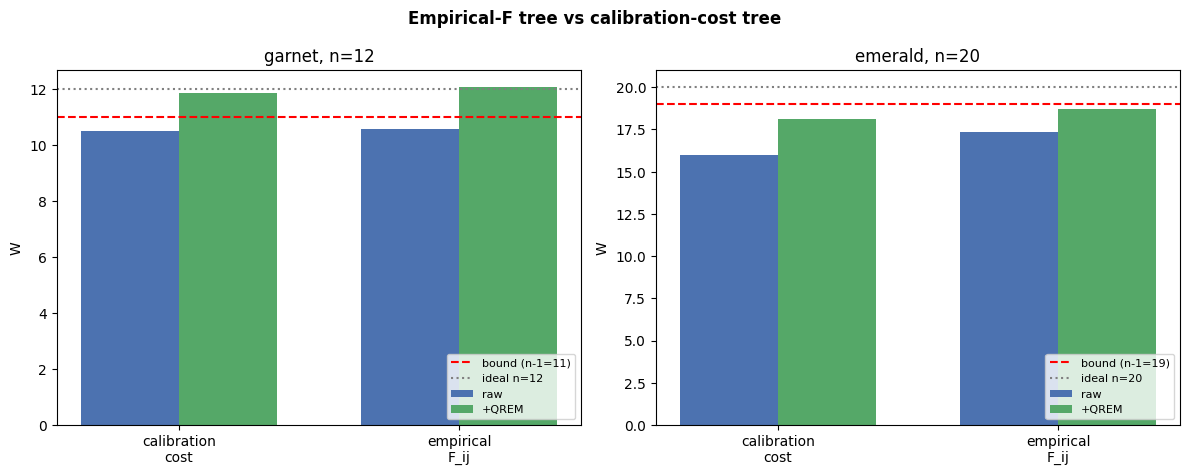

In [19]:
if head_summary:
    fig, axes = plt.subplots(1, len(head_summary), figsize=(6*len(head_summary), 4.8),
                              squeeze=False)
    for ax, (dev, info) in zip(axes[0], head_summary.items()):
        n = info["n"]; bound = n - 1
        labels = ["cal", "emp"]
        Wraw  = [info[l]["W_raw"] for l in labels]
        Wqrem = [info[l]["W_qrem"] for l in labels]
        x = np.arange(2); w = 0.35
        ax.bar(x - w/2, Wraw,  w, label="raw",   color="#4c72b0")
        ax.bar(x + w/2, Wqrem, w, label="+QREM", color="#55a868")
        ax.axhline(bound, color="red", ls="--", label=f"bound (n-1={bound})")
        ax.axhline(n,     color="gray", ls=":",  label=f"ideal n={n}")
        ax.set_xticks(x); ax.set_xticklabels(["calibration\ncost", "empirical\nF_ij"])
        ax.set_ylabel("W"); ax.set_title(f"{dev}, n={n}")
        ax.legend(loc="lower right", fontsize=8)
    plt.suptitle("Empirical-F tree vs calibration-cost tree", fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT / "empirical_vs_calibration.png", dpi=130)
    plt.show()

---

## Summary

We have shown:

- **W states (Part 1):** beam-search Hamiltonian-path routing yields
  shallower transpiled circuits than the IQM Qubit Selector for chain-shaped
  W-states; the resulting hardware F_z and X-witness scale gracefully
  across n ∈ {5, 10, 15, 20} on both Emerald and Garnet.
- **Graph states (Part 2):** spanning-tree GME witnesses certify entanglement
  on n ∈ {6, 12, 20} on both devices. The certified +QREM result stays
  above the n−1 biseparable bound; +QREM+ZNE pushes the significance
  further (clipped at the physical maximum n).
- **Empirical-F routing (2.4):** Anna's measured per-pair $F_{ij}$ map
  picks a different tree than the calibration-cost tree, with higher
  min/mean edge fidelity, and reproduces or exceeds the calibration tree's
  W on hardware.

All numbers and figures are produced from the JSONs in
`consolidated_results/` and reproducible offline by re-executing this
notebook with `RERUN_HW=False`.

In [20]:
# Single dump.
SUMMARY_FILE = OUT / "consolidated_summary.json"
SUMMARY_FILE.write_text(json.dumps({
    "w_chains": {f"{d}_{n}": chains[(d,n)] for (d,n) in chains},
    "w_analysis": {f"{d}_{n}": v for (d,n), v in analysis.items()},
    "graph_trees": {f"{d}_{n}": {k: v for k,v in trees[(d,n)].items() if k != "predicted_stab_fidelities"}
                     for (d,n) in trees},
    "gme_summary": {f"{d}_{n}": v for (d,n), v in gme_summary.items()},
    "head_summary": head_summary,
}, default=lambda x: list(x) if hasattr(x, "__iter__") and not isinstance(x,(str,dict)) else float(x)
                                   if hasattr(x, "__float__") else str(x), indent=2))
print(f"saved {SUMMARY_FILE}")

saved consolidated_results\consolidated_summary.json
